<a href="https://colab.research.google.com/github/dhfqoal/AI_LAB/blob/master/LAB_Regression_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score  , mean_absolute_error
from sklearn.metrics import confusion_matrix

plt.style.use("fivethirtyeight")

/tmp/ipython-input-2322532383.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.countplot(x="Hours Studied", data=df, palette="coolwarm")


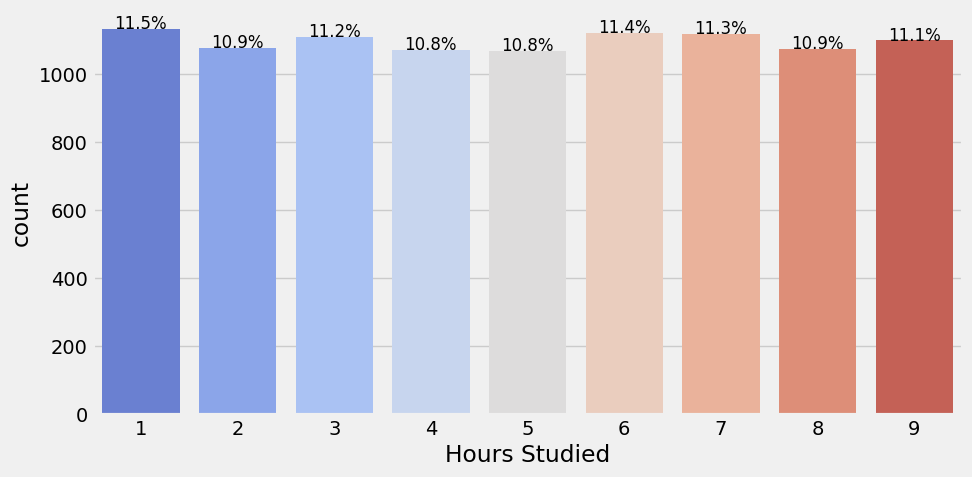

,Previous Scores,count
0,40-50,1609
1,50-60,1726
2,60-70,1637
3,70-80,1587
4,80-90,1680
5,90-100,1463


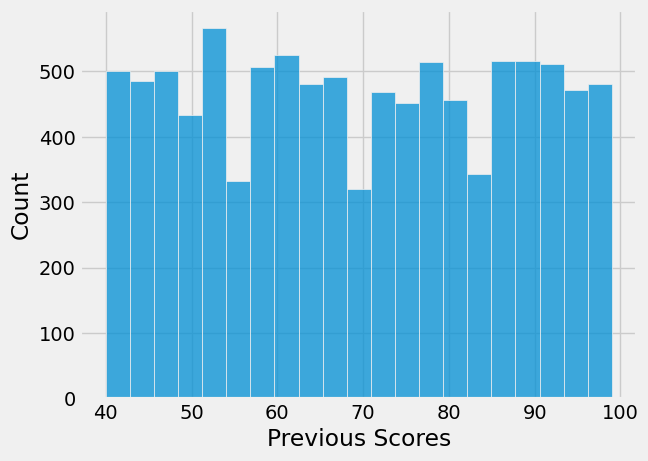

In [6]:
df=pd.read_csv(r"/content/Student_Performance.csv")
df
df.isna().sum()
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df["Hours Studied"].value_counts()
plt.figure(figsize=(10,5))
bar_plot = sns.countplot(x="Hours Studied", data=df, palette="coolwarm")
total = len(df["Hours Studied"])

for p in bar_plot.patches:
    bar_plot.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.5,
                  f'{(p.get_height() / total) * 100:.1f}%', ha='center', fontsize=12)

plt.show()

df["Previous Scores"].describe()
sns.histplot(x= df["Previous Scores"])
cut_series = pd.cut(df["Previous Scores"], bins=[40, 50, 60, 70, 80, 90, 100], labels=['40-50', '50-60', '60-70', '70-80', '80-90', '90-100'])
value_counts = cut_series.value_counts().sort_index()

value_counts.reset_index()

/tmp/ipython-input-3338549019.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.countplot(x="Sleep Hours", data=df, palette="coolwarm")


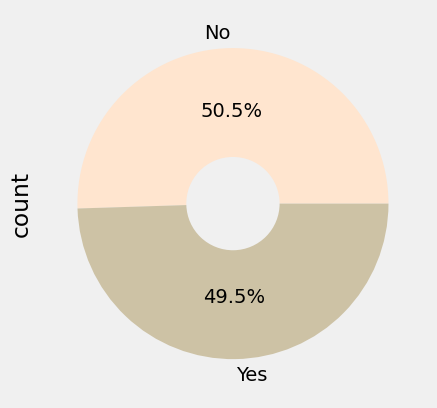

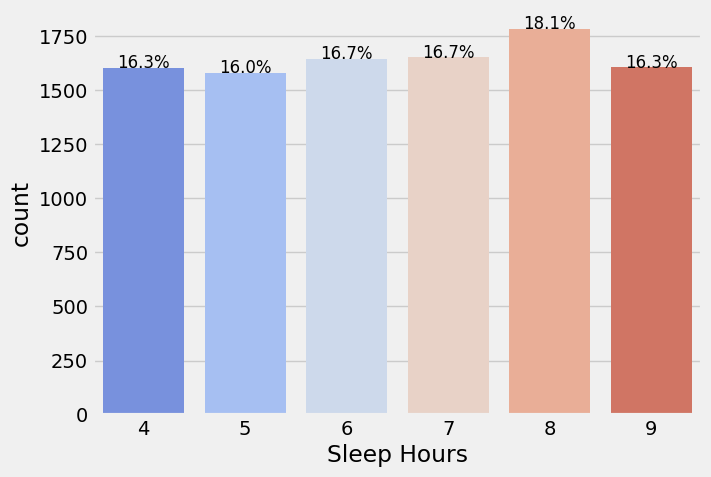

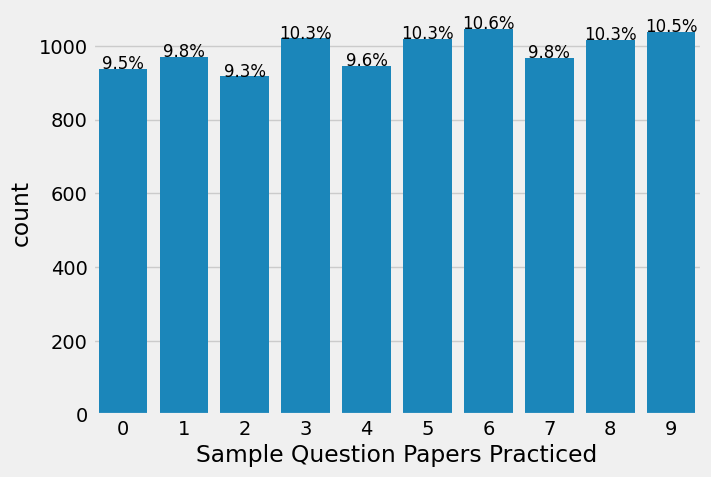

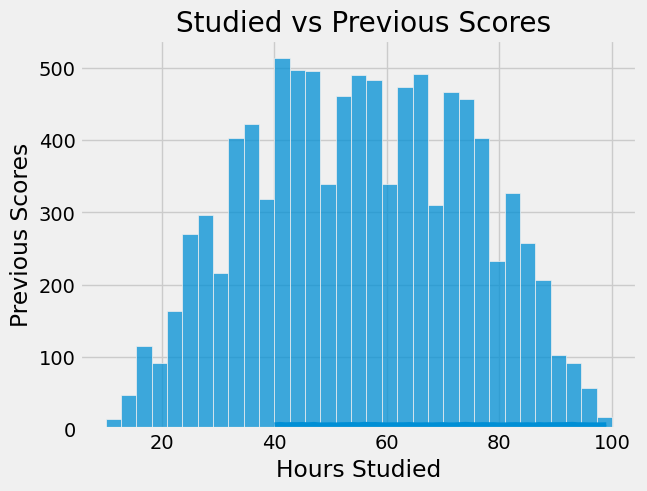

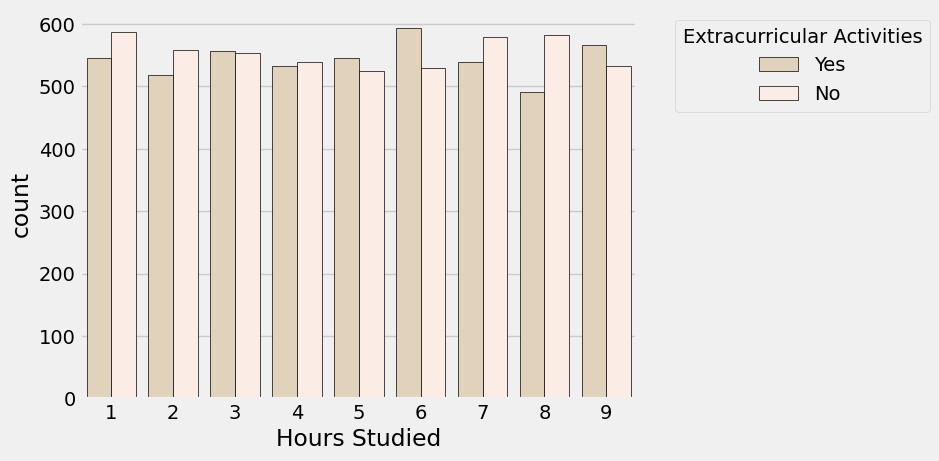

In [7]:
df["Extracurricular Activities"].value_counts()
df["Extracurricular Activities"].value_counts().plot(kind ="pie" , autopct='%1.1f%%', colors=["#FFE5CF" , "#CDC2A5"], explode=(0,0), wedgeprops=dict(width=0.7));
df["Sleep Hours"].describe()
df["Sleep Hours"].value_counts()

plt.figure(figsize=(7,5))
bar_plot = sns.countplot(x="Sleep Hours", data=df, palette="coolwarm")
total = len(df["Sleep Hours"])

for p in bar_plot.patches:
    bar_plot.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.5,
                  f'{(p.get_height() / total) * 100:.1f}%', ha='center', fontsize=12)

plt.show()

df["Sample Question Papers Practiced"].value_counts()


plt.figure(figsize=(7,5))
bar_plot = sns.countplot(x="Sample Question Papers Practiced", data=df)
total = len(df["Sample Question Papers Practiced"])

for p in bar_plot.patches:
    bar_plot.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.5,
                  f'{(p.get_height() / total) * 100:.1f}%', ha='center', fontsize=12)

plt.show()

df["Performance Index"].describe()

sns.histplot(x= df["Performance Index"])

sns.lineplot(y=df['Hours Studied'], x=df['Previous Scores'])
plt.xlabel('Hours Studied')
plt.ylabel('Previous Scores')
plt.title(' Studied vs Previous Scores')
plt.show()

df.groupby(["Extracurricular Activities"])["Hours Studied"].value_counts().unstack()

sns.countplot(data=df, hue="Extracurricular Activities", x="Hours Studied" ,  palette=["#E7D4B5" ,"#FEECE2"] ,edgecolor="black")
plt.legend(title='Extracurricular Activities', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [8]:
grouped_data= df.groupby("Hours Studied")["Sleep Hours"].value_counts().unstack()
grouped_data

Sleep Hours,4,5,6,7,8,9
Hours Studied,,,,,,
1,170,177,175,199,233,179
2,200,157,200,166,176,178
3,192,177,182,178,188,193
4,166,163,180,186,207,169
5,163,182,183,181,205,155
6,207,187,183,182,190,173
7,168,170,184,189,211,196
8,168,197,195,172,175,167
9,171,170,163,200,199,196


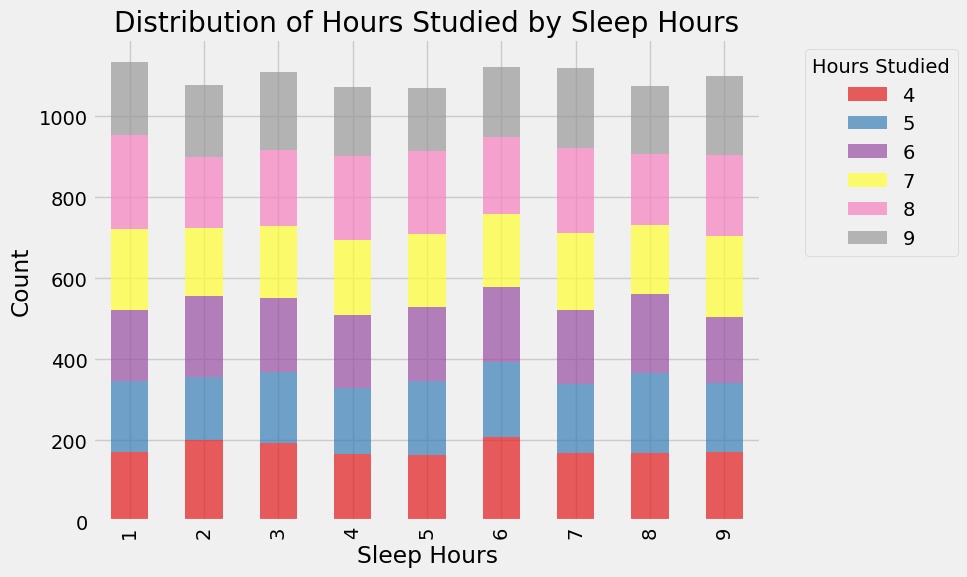

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

grouped_data = df.groupby("Hours Studied")["Sleep Hours"].value_counts().unstack(fill_value=0)


plt.figure(figsize=(10, 6))


grouped_data.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='Set1', alpha=0.7)


plt.title('Distribution of Hours Studied by Sleep Hours')
plt.xlabel('Sleep Hours')
plt.ylabel('Count')
plt.legend(title='Hours Studied', bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()


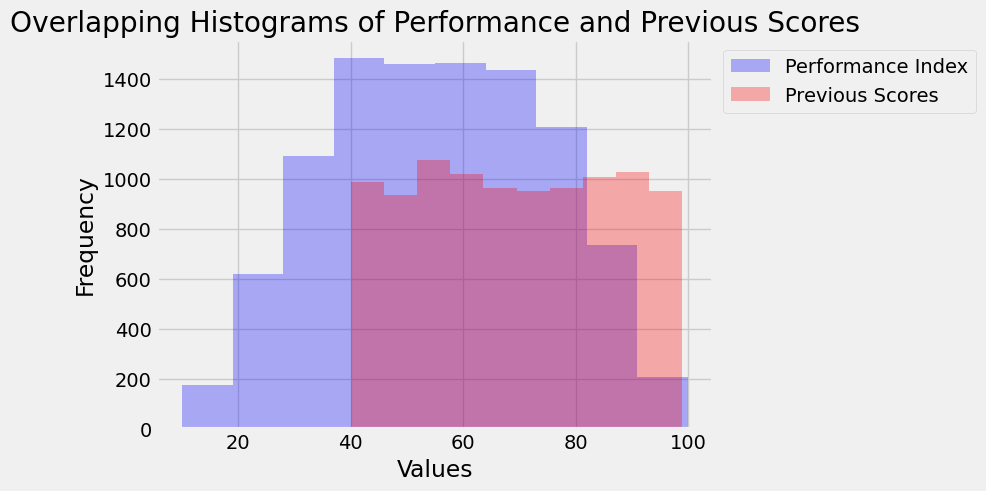

In [10]:
papers_practiced = df['Performance Index']
previous_scores = df['Previous Scores']

plt.hist(papers_practiced, bins=10, alpha=0.3, label='Performance Index', color='blue')
plt.hist(previous_scores, bins=10, alpha=0.3, label='Previous Scores', color='red')

plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Overlapping Histograms of Performance and Previous Scores')
plt.legend( bbox_to_anchor=(1, 1), loc='upper left')

plt.show()


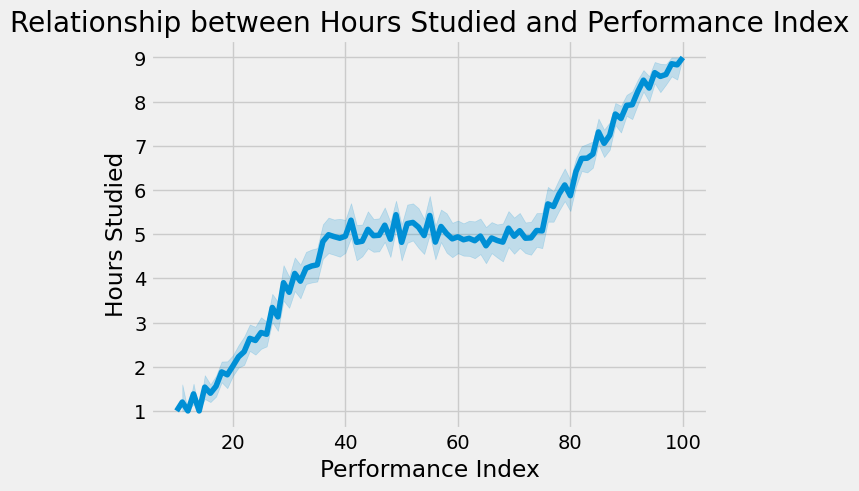

In [11]:
sns.lineplot(data=df, y='Hours Studied', x='Performance Index')

plt.title('Relationship between Hours Studied and Performance Index')
plt.ylabel('Hours Studied')
plt.xlabel('Performance Index')
plt.show()

<Axes: xlabel='Previous Scores', ylabel='Performance Index'>

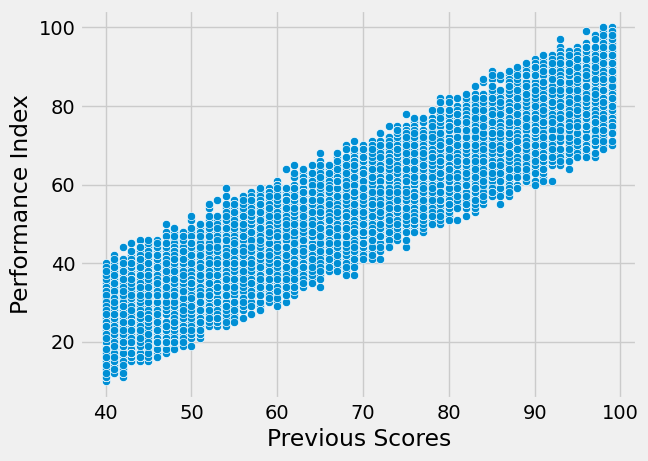

In [12]:
sns.scatterplot(x='Previous Scores' , y='Performance Index', data=df)


In [13]:
label_encoder = LabelEncoder()

df['Extracurricular Activities'] = label_encoder.fit_transform(df['Extracurricular Activities'])


In [14]:
X = df.drop(columns=['Performance Index'])
y = df['Performance Index']


In [15]:
X

y

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0
...,...
9995,23.0
9996,58.0
9997,74.0
9998,95.0


In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.drop(["Extracurricular Activities"] ,axis=1))
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))


In [17]:
column= X[["Extracurricular Activities"]]
X_combined = np.hstack((X_scaled, column.values))

X_train, X_test, y_train, y_test = train_test_split(X_combined, y_scaled, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")



Mean Squared Error: 0.011671265615520255


Mean Absolute Error (MAE): 0.0857457795076857
Root Mean Squared Error (RMSE): 0.10803363187230287
Predicted Performance Index: [93.89895519]


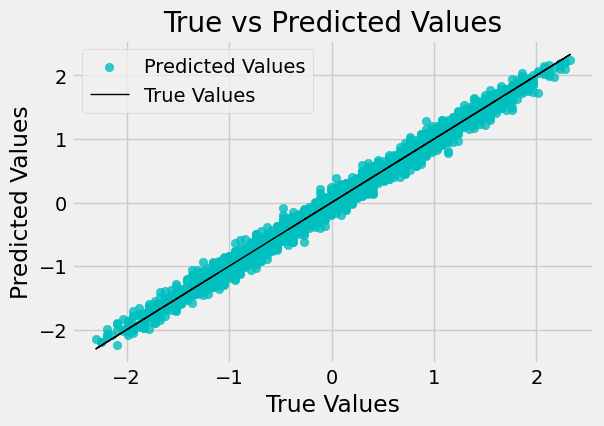

In [18]:
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae}")

rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(y_test, y_pred, c="c", alpha=0.8, label="Predicted Values")

ax.plot(y_test, y_test, c="k", lw=1, label="True Values")

ax.set_xlabel('True Values')
ax.set_ylabel('Predicted Values')
ax.set_title('True vs Predicted Values')
ax.legend()

input_data = np.array([[7, 99, 0, 9, 1]])

y_pred = model.predict(input_data)

print("Predicted Performance Index:", y_pred[0])

model.coef_

model.intercept_

def feature_importance_df():
    coef = model.coef_.reshape(-1)
    features = X.columns.tolist()

    return pd.DataFrame({'Features': features, 'Coefficients': coef})

feature_importance = feature_importance_df()


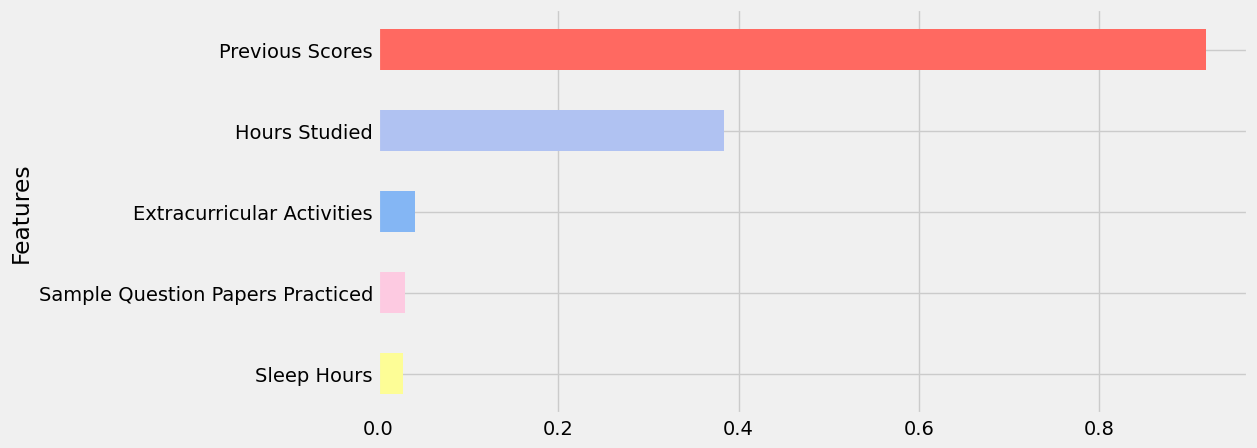

['linear_model.pkl']

In [19]:
feature_importance.groupby('Features')['Coefficients'].max().sort_values(ascending = False)

fig = plt.subplots(1,1,figsize = (10,5))

feature_importance.groupby('Features')['Coefficients'].max().sort_values(ascending = True).plot(kind = 'barh',
                                                                                                color = ['#fdfd96','#fdcae1',
                                                                                                         '#84b6f4','#b0c2f2',                                                                                                       '#ff6961','#77dd77'])
plt.show()

import joblib
joblib.dump(model,'linear_model.pkl')

In [20]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
print("Imported Ridge, Lasso, and RandomForestRegressor successfully.")

Imported Ridge, Lasso, and RandomForestRegressor successfully.


In [21]:
ridge_model = Ridge(random_state=42)
lasso_model = Lasso(random_state=42)
rf_model = RandomForestRegressor(random_state=42)
linear_model = LinearRegression()

print("Ridge, Lasso, RandomForestRegressor, and Linear Regression models initialized successfully.")

Ridge, Lasso, RandomForestRegressor, and Linear Regression models initialized successfully.


In [22]:
models = {
    "Linear Regression": linear_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "Random Forest": rf_model
}

performance_metrics = {}

for name, model in models.items():
    print(f"\nTraining and evaluating {name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"  Mean Squared Error (MSE): {mse:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  R-squared (R2): {r2:.4f}")

    performance_metrics[name] = {"MSE": mse, "MAE": mae, "R2": r2}

print("\nAll models trained and evaluated.")


Training and evaluating Linear Regression...
  Mean Squared Error (MSE): 0.0117
  Mean Absolute Error (MAE): 0.0857
  R-squared (R2): 0.9884

Training and evaluating Ridge...
  Mean Squared Error (MSE): 0.0117
  Mean Absolute Error (MAE): 0.0857
  R-squared (R2): 0.9884

Training and evaluating Lasso...
  Mean Squared Error (MSE): 1.0097
  Mean Absolute Error (MAE): 0.8462
  R-squared (R2): -0.0010

Training and evaluating Random Forest...


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


  Mean Squared Error (MSE): 0.0153
  Mean Absolute Error (MAE): 0.0990
  R-squared (R2): 0.9848

All models trained and evaluated.


In [23]:
models = {
    "Linear Regression": linear_model,
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "Random Forest": rf_model
}

performance_metrics = {}

for name, model in models.items():
    print(f"\nTraining and evaluating {name}...")

    # Train the model, flattening y_train
    model.fit(X_train, y_train.ravel())

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate the model, flattening y_test for comparison
    mse = mean_squared_error(y_test.ravel(), y_pred)
    mae = mean_absolute_error(y_test.ravel(), y_pred)
    r2 = r2_score(y_test.ravel(), y_pred)

    print(f"  Mean Squared Error (MSE): {mse:.4f}")
    print(f"  Mean Absolute Error (MAE): {mae:.4f}")
    print(f"  R-squared (R2): {r2:.4f}")

    performance_metrics[name] = {"MSE": mse, "MAE": mae, "R2": r2}

print("\nAll models trained and evaluated.")


Training and evaluating Linear Regression...
  Mean Squared Error (MSE): 0.0117
  Mean Absolute Error (MAE): 0.0857
  R-squared (R2): 0.9884

Training and evaluating Ridge...
  Mean Squared Error (MSE): 0.0117
  Mean Absolute Error (MAE): 0.0857
  R-squared (R2): 0.9884

Training and evaluating Lasso...
  Mean Squared Error (MSE): 1.0097
  Mean Absolute Error (MAE): 0.8462
  R-squared (R2): -0.0010

Training and evaluating Random Forest...
  Mean Squared Error (MSE): 0.0153
  Mean Absolute Error (MAE): 0.0990
  R-squared (R2): 0.9848

All models trained and evaluated.


In [24]:
performance_df = pd.DataFrame.from_dict(performance_metrics, orient='index')

performance_df['RMSE'] = np.sqrt(performance_df['MSE'])

print("Model Performance Comparison:")
print(performance_df.sort_values(by='R2', ascending=False))

best_model_r2 = performance_df.sort_values(by='R2', ascending=False).index[0]
best_model_mse = performance_df.sort_values(by='MSE', ascending=True).index[0]
best_model_mae = performance_df.sort_values(by='MAE', ascending=True).index[0]

print(f"\nBased on R-squared, '{best_model_r2}' performed best with an R2 score of {performance_df.loc[best_model_r2]['R2']:.4f}.")
print(f"Considering MSE, '{best_model_mse}' had the lowest value of {performance_df.loc[best_model_mse]['MSE']:.4f}, and for MAE, '{best_model_mae}' had the lowest value of {performance_df.loc[best_model_mae]['MAE']:.4f}.")

Model Performance Comparison:
                        MSE       MAE        R2      RMSE
Linear Regression  0.011671  0.085746  0.988430  0.108034
Ridge              0.011671  0.085745  0.988430  0.108034
Random Forest      0.015319  0.099035  0.984814  0.123770
Lasso              1.009749  0.846152 -0.000978  1.004863

Based on R-squared, 'Linear Regression' performed best with an R2 score of 0.9884.
Considering MSE, 'Linear Regression' had the lowest value of 0.0117, and for MAE, 'Ridge' had the lowest value of 0.0857.
